# Data and the State (DATA 21905/31905)
# Lab 2: The Decennial Census (blocks) and the ACS

In Lab 1, we explored the most famous and essential dataset published by the U.S. Census Bureau at the **county** level in Illinois. In this lab we go deeper in two directions:

1. **Finer geography:** from counties down to individual census **blocks**, the smallest unit in the Census hierarchy.
2. **Richer data:** from the decennial Census to the **American Community Survey (ACS)**, which covers income, housing, commuting, education, and much more.

By the end, we'll combine race data with socioeconomic variables to ask questions about neighborhood composition — and run into a classic statistical pitfall along the way.

In [ ]:
!pip install -q census us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 4.7 MB/s eta 0:00:00


In [1]:
%config InlineBackend.figure_formats = ["svg"]

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from census import Census
from us import states

state_fips  = "17"    # Illinois
county_fips = "031"   # Cook County
state_name  = "Illinois"
county_name = "Cook County"

census = Census("", year=2020)

In [2]:
# @title Check the census API is working
try:
    county_populations = census.pl.get(
        ("NAME"),
        geo={"for": "state:17"}
    )
except Exception:
    raise RuntimeError(
        "Error fetching data from the Census API. "
        "Please try disconnecting and reconnecting the runtime. "
        "If the problem persists after 2 resets, you will need to use our backup data cells to "
        "complete the lab"
    )

## Section 1 -- The Central Spine

## Section 2 — GEOIDs and Block Level Data

Census **blocks** are the smallest unit in the hierarchy. While counties vary widely in population and tracts are designed for comparability, blocks follow physical features — streets, waterways, property lines. Some blocks have hundreds of people; many have zero.

Here we'll fetch the same P1 race table from Lab 1, but at block resolution for Cook County. The API call structure is identical; we just change `"for": "county:*"` to `"for": "block:*"` and specify the county. **Cook County has roughly 43,000 blocks**, so this could take up to a minute.

In [3]:
# We will repeat some of the work from Notebook 1 here
p1_population_columns = {
    "P1_003N": "White",     # White alone
    "P1_004N": "Black",     # Black or African American alone
    "P1_005N": "AMIN",      # American Indian and Alaska Native alone
    "P1_006N": "Asian",     # Asian alone
    "P1_007N": "NHPI",      # Native Hawaiian and Other Pacific Islander alone
    "P1_008N": "SomeOther", # Some Other Race alone
    "P1_009N": "Multi",     # Population of two or more races
}
pl_race_categories = list(p1_population_columns.values())

block_populations = census.pl.get(
    ("NAME", *p1_population_columns),
    geo={
        "for": "block:*",   # Note: we changed the "for" statement to include blocks
        "in": f"county:{county_fips} state:{state_fips}", # We now modify the "in" statment to include 
                                                          # both the county and state FIPS codes
    },
)

print(f"Fetched data for {len(block_populations):,} blocks.")

# now let's make sure we're using human-readable columns, as chosen above
block_race_df = pd.DataFrame(block_populations).rename(
    columns={"NAME": "name", **p1_population_columns}
)

Fetched data for 83,018 blocks.


<font color="red"> Say something about the construction of 15 character geoids here <font>

In [4]:
# this constructs the 15-digit complete GEOID by concatenating the pieces
# describing different hierarchical levels: state(2) + county(3) + tract(6) + block(4)
block_race_df["GEOID20"] = (
    block_race_df["state"]
    + block_race_df["county"]
    + block_race_df["tract"]
    + block_race_df["block"]
)

block_race_df

,name,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,state,county,tract,block,GEOID20
0,"Block 1000, Block Group 1, Census Tract 101, C...",89.0,26.0,3.0,5.0,0.0,4.0,7.0,17,031,010100,1000,170310101001000
1,"Block 1001, Block Group 1, Census Tract 101, C...",33.0,3.0,0.0,6.0,0.0,8.0,13.0,17,031,010100,1001,170310101001001
2,"Block 1002, Block Group 1, Census Tract 101, C...",108.0,94.0,1.0,11.0,1.0,50.0,51.0,17,031,010100,1002,170310101001002
3,"Block 1003, Block Group 1, Census Tract 101, C...",23.0,10.0,0.0,5.0,0.0,1.0,14.0,17,031,010100,1003,170310101001003
4,"Block 2001, Block Group 2, Census Tract 101, C...",21.0,313.0,0.0,0.0,0.0,15.0,23.0,17,031,010100,2001,170310101002001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83013,"Block 0005, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0005,170319900000005
83014,"Block 0001, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0001,170319900000001
83015,"Block 0003, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0003,170319900000003
83016,"Block 0004, Block Group 0, Census Tract 9900, ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,17,031,990000,0004,170319900000004


In [5]:
# The GEOID is a unique identifier for each block, which makes it a good choice as an index for our
# dataframe.
block_race_df = block_race_df.set_index("GEOID20")

# ⚠️ NEW SYNTAX: We have encoded all of the information that is present in the columns
# "name", "state", "county", "tract", and "block" into the GEOID20 column, so we can remove (drop) 
# those extra columns.
block_race_df = block_race_df.drop(
    columns=["name", "state", "county", "tract", "block"]
)

# Now we convert the population columns to integers, which is good data practice since we expect that
# all of these values to be integers. This is a good practice since some real world data will be 
# stored as values using string syntax (e.g. "2948") which can then cause problems when we try to 
# do arithmetic with those data columns.
block_race_df[pl_race_categories] = block_race_df[pl_race_categories].astype(int)

block_race_df["total"] = block_race_df[pl_race_categories].sum(axis=1)
block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total
GEOID20,,,,,,,,
170310101001000,89,26,3,5,0,4,7,134
170310101001001,33,3,0,6,0,8,13,63
170310101001002,108,94,1,11,1,50,51,316
170310101001003,23,10,0,5,0,1,14,53
170310101002001,21,313,0,0,0,15,23,372
...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0
170319900000001,0,0,0,0,0,0,0,0
170319900000003,0,0,0,0,0,0,0,0


In [6]:
# Now we can compute the percentage of each racial category for each block, being careful to 
# handle zero division errors by filling NaN values with 0.
for col in pl_race_categories:
    block_race_df[f"{col}_pct"] = (
        100 * block_race_df[col] / block_race_df["total"]
    ).fillna(0) # <- this fills any NaN values with 0, which can happen when the total population is 0

block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
GEOID20,,,,,,,,,,,,,,,
170310101001000,89,26,3,5,0,4,7,134,66.417910,19.402985,2.238806,3.731343,0.000000,2.985075,5.223881
170310101001001,33,3,0,6,0,8,13,63,52.380952,4.761905,0.000000,9.523810,0.000000,12.698413,20.634921
170310101001002,108,94,1,11,1,50,51,316,34.177215,29.746835,0.316456,3.481013,0.316456,15.822785,16.139241
170310101001003,23,10,0,5,0,1,14,53,43.396226,18.867925,0.000000,9.433962,0.000000,1.886792,26.415094
170310101002001,21,313,0,0,0,15,23,372,5.645161,84.139785,0.000000,0.000000,0.000000,4.032258,6.182796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170319900000001,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170319900000003,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


That dataframe view shows that some blocks have zero people, while others have hundreds. Let's get a sense of the largest and smallest.

In [7]:
# sorts by total population, largest to smallest
block_race_df.sort_values("total", ascending=False)

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
GEOID20,,,,,,,,,,,,,,,
170318435001012,430,3482,8,32,0,325,412,4689,9.170399,74.258904,0.170612,0.682448,0.000000,6.931115,8.786522
170313201011003,2099,124,3,737,0,64,256,3283,63.935425,3.777033,0.091380,22.448980,0.000000,1.949436,7.797746
170313201013003,1719,125,13,687,0,52,246,2842,60.485574,4.398311,0.457424,24.173118,0.000000,1.829697,8.655876
170313907003004,420,1080,1,706,0,50,116,2373,17.699115,45.512010,0.042141,29.751370,0.000000,2.107038,4.888327
170317608011013,852,129,1,1075,2,102,103,2264,37.632509,5.697880,0.044170,47.482332,0.088339,4.505300,4.549470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170318131004013,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170318131004011,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
170318131004010,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#### TASK 1

What is the GEOID20 of the most populous block in Cook County? What is its population?

Can you also find the most populous block that is majority Black? Majority White?

In [8]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

#### TASK 2

How many blocks in Cook County are **majority Black** (more than 50% Black population)? How many are **majority White**?

_Hint: use boolean filtering as in Lab 1. Think about whether it makes sense to include zero-population blocks._

In [9]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

### Population Distribution and Power Laws

Recall from Lab 1 that a histogram of `AMIN_pct` across Illinois counties showed most counties were well below 1% — a highly right-skewed distribution. Let's see what the histogram of `Black_pct` looks like across Cook County **blocks**.

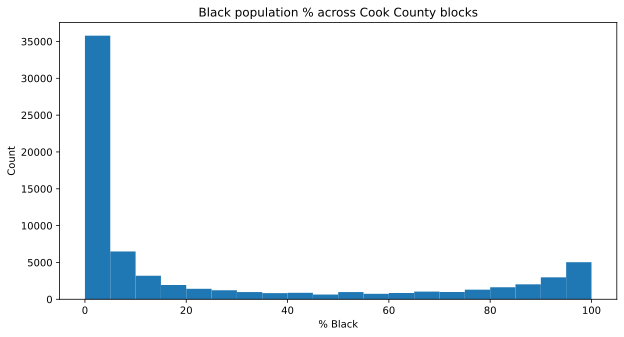

In [10]:
# ⚠️ NEW SYNTAX: When filtering, you can use the notation `df.loc[mask]`. This is the most robust way to
# filter a dataframe when queries get complicated, but you will also see the syntax `df[mask]` used frequently.
populated_blocks_df = block_race_df[block_race_df["total"] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

# histogram of Black% across populated blocks
ax.hist(populated_blocks_df["Black_pct"], bins=20)
ax.set_xlabel("% Black")
ax.set_ylabel("Count")
ax.set_title(f"Black population % across {county_name} blocks")
plt.show()

Notice the shape: it's roughly **bimodal**, with a large peak near 0% and another peak near 100%, and relatively few blocks in between. This is a quantitative signature of residential segregation — blocks in Cook County tend to be either predominantly Black or predominantly non-Black, with not much mixing at the block level.

Compare this to what you'd see if you made a histogram of `Black_pct` across Illinois *counties* from Lab 1 — it's a very different picture.

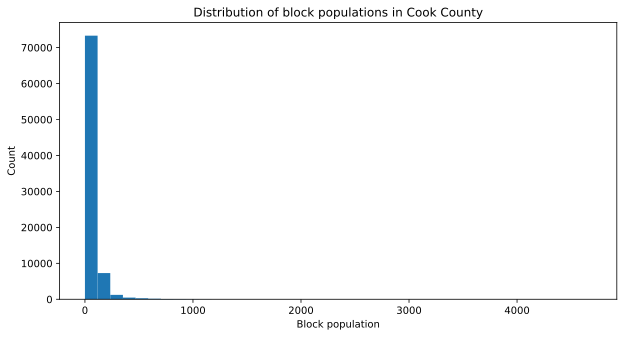

In [11]:
# histogram of block *populations* — how many people live in each block?
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=40)
ax.set_xlabel("Block population")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of block populations in {county_name}")
plt.show()

That viz is pretty lousy, for a few reasons. Discuss!

We'll walk through a few alternatives just to give you ideas.  A core skill you are trying to build is making good viz, and there's a lot of data-common-sense that goes into that.

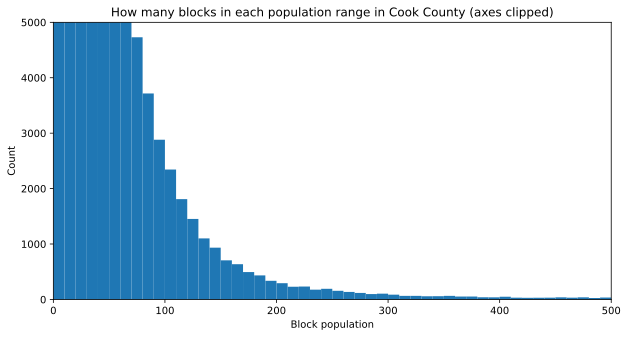

In [12]:
# a version that clips both axes
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=range(0, 510, 10))
ax.set_xlim(0, 500)
ax.set_ylim(0, 5000)
ax.set_xlabel("Block population")
ax.set_ylabel("Count")
ax.set_title(f"How many blocks in each population range in {county_name} (axes clipped)")
plt.show()

Most blocks have very small populations — many are zero. A few are very large. This kind of highly right-skewed distribution is typical of lots of statistics -- not just population of Census blocks.  This kind of shape is called a [power law](https://en.wikipedia.org/wiki/Power_law).

In [13]:
block_race_df["total"].max()

np.int64(4689)

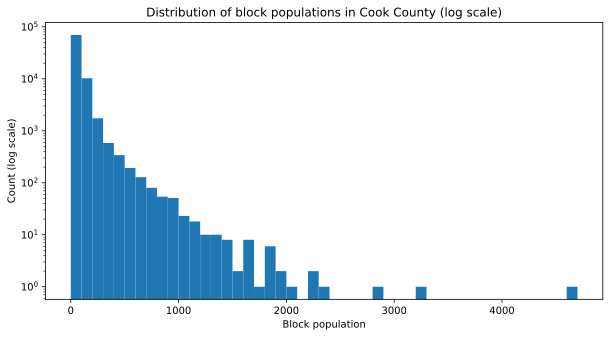

In [14]:
# let's switch to a log scale instead
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(block_race_df["total"], bins=range(0, 4800, 100)) # play around with bin size!!
ax.set_yscale("log")
ax.set_xlabel("Block population")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Distribution of block populations in {county_name} (log scale)")
plt.show()

Now let's compare this with the county-level data.

<font color="red"> Better transition here <font>

In [15]:
# @title This cell gets county-level population data for IL and saves to `county_race_df`

county_populations = census.pl.get(
    ("NAME", *p1_population_columns),
    geo={"for": "county:*", "in": f"state:{state_fips}"},
)
county_race_df = (
    pd.DataFrame(county_populations)
    .rename(columns={"NAME": "name", **p1_population_columns})
    .set_index("name")
    .drop(columns=["state", "county"])
)
county_race_df[pl_race_categories] = county_race_df[pl_race_categories].astype(int)
county_race_df["total"] = county_race_df[pl_race_categories].sum(axis=1)
for col in pl_race_categories:
    county_race_df[f"{col}_pct"] = (100 * county_race_df[col] / county_race_df["total"]).fillna(0)

print("First 5 rows of 'county_race_df':")
county_race_df.head()

First 5 rows of 'county_race_df':


,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
name,,,,,,,,,,,,,,,
"Adams County, Illinois",58837,2501,104,513,39,526,3217,65737,89.503628,3.804555,0.158206,0.780382,0.059327,0.800158,4.893743
"Alexander County, Illinois",3311,1617,24,6,0,20,262,5240,63.187023,30.858779,0.458015,0.114504,0.000000,0.381679,5.000000
"Bond County, Illinois",14446,1077,52,105,11,360,674,16725,86.373692,6.439462,0.310912,0.627803,0.065770,2.152466,4.029895
"Boone County, Illinois",38766,1245,498,659,24,6176,6080,53448,72.530310,2.329367,0.931747,1.232974,0.044903,11.555156,11.375543
"Brown County, Illinois",4779,1054,11,12,0,210,178,6244,76.537476,16.880205,0.176169,0.192184,0.000000,3.363229,2.850737


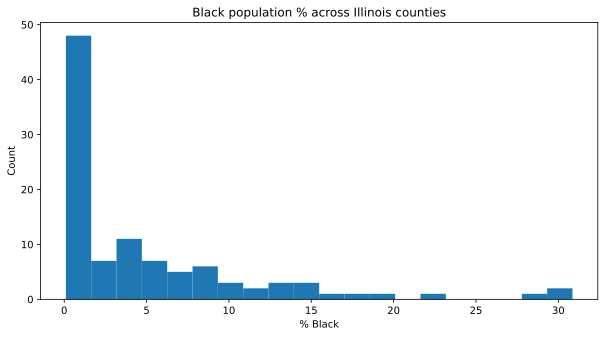

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(county_race_df["Black_pct"], bins=20)
ax.set_xlabel("% Black")
ax.set_ylabel("Count")
ax.set_title(f"Black population % across {state_name} counties")
plt.show()

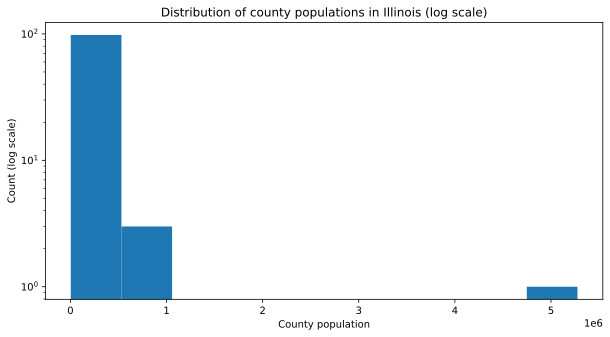

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(county_race_df["total"])
ax.set_yscale("log")
ax.set_xlabel("County population")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Distribution of county populations in {state_name} (log scale)")
plt.show()

Gee, I wonder what that county out on the right is? Let's look at the data without Cook County included.

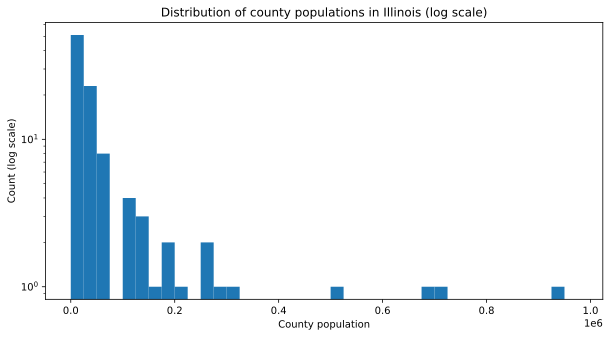

In [18]:
# First we will build a mask to filter out Cook County.

# ⚠️ NEW SYNTAX: When creating a mask, you can either create a mask on using columns using the syntax
# block_race_df["total"] > 0, or you can create a mask using the index of the dataframe which is useful
# for excluding specific geographies by name.
not_cook_county_mask = county_race_df.index != "Cook County, Illinois"

fig, ax = plt.subplots(figsize=(10, 5))

# We now use the mask that we constructed earlier to filter out Cook County from the dataframe
# and then combine this with the column access syntax to select the "total" column of the filtered dataframe.
ax.hist(county_race_df.loc[not_cook_county_mask, ["total"]], bins = np.arange(0, 1000000, 25000))
ax.set_yscale("log")
ax.set_xlabel("County population")
ax.set_ylabel("Count (log scale)")
ax.set_title(f"Distribution of county populations in {state_name} (log scale)")
plt.show()

## Section 3 — The American Community Survey (ACS)

The ACS has much richer socio-economic variables. We'll start by making a tract-level dataframe that includes median age and median income.

In addition to publishing decennial data, the U.S. Census Bureau publishes [American Community Survey](https://www.census.gov/programs-surveys/acs) (ACS) data every year. The ACS is sent to a random sample of U.S. addresses; it is an invaluable source for understanding economic and social trends. The key tradeoffs versus the decennial:

| | Decennial Census | ACS 5-year estimates |
|---|---|---|
| Coverage | Full count | ~3.5M households/year (sample) |
| Frequency | Every 10 years | Annually (pooled over 5 years) |
| Variables | Demographics only | Demographics + socioeconomics |
| Smallest unit | Block | Tract (usually) |
| Uncertainty | Exact counts | Has margins of error |



*Note:* You may eventually want to explore different kinds of information available from the ACS. One way to do this is to look at the associated documentation. Specifically, you can find relevant variables and table IDs by looking at the ["ACS Detailed Table Shells"](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.2023.html#list-tab-79594641) located on the Census website. Additionally, we put together a [Google sheets workbook](https://docs.google.com/spreadsheets/d/1DtGNarbQLaJdtMiINQ7brQ-Y6zawBkkBkp0VGSENsZw/edit?usp=sharing) that organizes this information for the 2023–2015 ACS and the 2020 and 2010 decennial census.

In [19]:
# Estimate!!Median age --!!Total:
median_age_column = "B01002_001E"

# Estimate!!Median household income in the past 12 months:
median_income_column = "B19013_001E"

# Means of Transportation to Work: total commuters, and public transit users
commuters_total_column = "B08301_001E"
transit_column         = "B08301_010E"

In [20]:
county_tract_acs_df = pd.DataFrame(
    census.acs5.get(
        (median_age_column, median_income_column, commuters_total_column, transit_column),
        geo={
            "for": "tract:*",  # Note: we changed the "for" statement to include tracts instead of blocks
            "in": f"county:{county_fips} state:{state_fips}",
        },
        year=2023,
    )
)

# Let's go ahead and rename the columns to something more human-readable
county_tract_acs_df = county_tract_acs_df.rename(columns={
    median_age_column:      "median_age",
    median_income_column:   "median_income",
    commuters_total_column: "commuters_total",
    transit_column:         "transit_riders",
})


# Construct the GEOID column 
county_tract_acs_df["GEOID"] = (
    county_tract_acs_df["state"]
    + county_tract_acs_df["county"]
    + county_tract_acs_df["tract"]
)

county_tract_acs_df = county_tract_acs_df.set_index("GEOID")

# We have encoded all of the information that is present in the columns
# "state", "county", and "tract" into the GEOID, so we can drop those columns now.
county_tract_acs_df = county_tract_acs_df.drop(columns=["state", "county", "tract"])


county_tract_acs_df

,median_age,median_income,commuters_total,transit_riders
GEOID,,,,
17031010100,46.1,69460.0,2279.0,571.0
17031010201,34.9,49639.0,3681.0,903.0
17031010202,38.0,55119.0,1292.0,493.0
17031010300,49.5,65871.0,3664.0,1042.0
17031010400,29.2,49017.0,2150.0,721.0
...,...,...,...,...
17031844600,40.8,56848.0,772.0,168.0
17031844700,36.2,69583.0,958.0,173.0
17031980000,-666666666.0,-666666666.0,0.0,0.0


Something very strange has happened!  There are tracts with negative values in the millions. This is sometimes called a **sentinel value** — dummy data used to flag when something doesn't fit. (It's an alternative to `NaN`, or "not a number.") The Census uses large negative numbers to mean "estimate not available for this tract.""

In [21]:
# how many of these are negative?
print("median age negative in",    (county_tract_acs_df["median_age"] < 0).sum(),    "tracts")
print("median income negative in", (county_tract_acs_df["median_income"] < 0).sum(), "tracts")

# replace sentinel values with NaN
sentinal_value_mask = county_tract_acs_df < 0
county_tract_acs_df[sentinal_value_mask] = np.nan

# derived variable: transit commute share
county_tract_acs_df["transit_pct"] = (
    100 * county_tract_acs_df["transit_riders"] / county_tract_acs_df["commuters_total"]
)

# Sort by transit commute share, largest to smallest
county_tract_acs_df = county_tract_acs_df.sort_values("transit_pct", ascending=False)
county_tract_acs_df

median age negative in 4 tracts
median income negative in 15 tracts


,median_age,median_income,commuters_total,transit_riders,transit_pct
GEOID,,,,,
17031400800,23.9,22648.0,1053.0,612.0,58.119658
17031070103,26.8,76477.0,1304.0,706.0,54.141104
17031670800,41.5,43145.0,451.0,241.0,53.436807
17031350400,32.5,20938.0,471.0,245.0,52.016985
17031271800,42.5,51550.0,415.0,215.0,51.807229
...,...,...,...,...,...
17031816200,37.8,92943.0,2377.0,0.0,0.000000
17031381700,NaN,NaN,0.0,0.0,NaN
17031980000,NaN,NaN,0.0,0.0,NaN


### Visualizing ACS data

Armed with clean data, let's visualize the distributions of income and age across Cook County tracts.

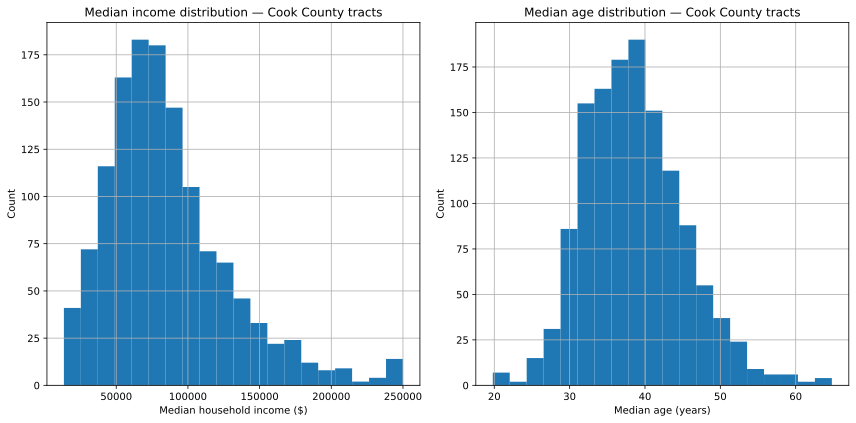

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

county_tract_acs_df["median_income"].dropna().hist(bins=20, ax=axes[0])
axes[0].set_xlabel("Median household income ($)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Median income distribution — {county_name} tracts")

county_tract_acs_df["median_age"].dropna().hist(bins=20, ax=axes[1])
axes[1].set_xlabel("Median age (years)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Median age distribution — {county_name} tracts")

plt.tight_layout()
plt.show()

We can also look at which tracts have the highest public transit commute share — a natural variable of interest in a city like Chicago.

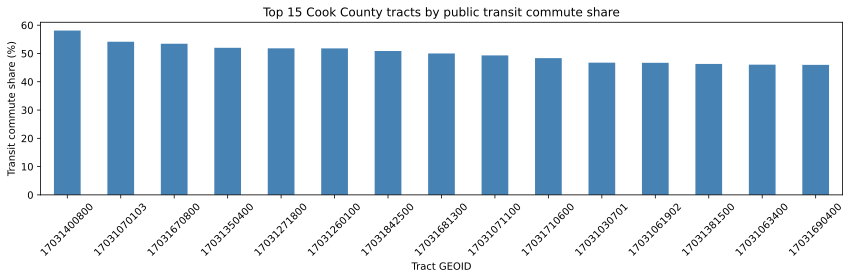

In [23]:
top_transit = (
    county_tract_acs_df["transit_pct"]
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)
ax = top_transit.plot.bar(figsize=(12, 4), color="steelblue")
ax.set_xlabel("Tract GEOID")
ax.set_ylabel("Transit commute share (%)")
ax.set_title(f"Top 15 {county_name} tracts by public transit commute share")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [24]:
occupation_by_median_earnings_columns = {
    "B24011_002E": "Mgmt/Science/Arts",             # Management, business, science, and arts occupations
    "B24011_018E": "Service",                       # Service occupations
    "B24011_026E": "Sales/Office",                  # Sales and office occupations
    "B24011_029E": "Natural Res./Constr./Maint.",   # Natural resources, construction, and maintenance occupations
    "B24011_033E": "Prod./Transport/Material Mvmt", # Production, transportation, and material moving occupations
}

# Now we do the standard rigmarole to fetch the data, rename columns, construct the GEOID, 
# and filter out sentinel values

occupation_columns = list(occupation_by_median_earnings_columns.keys())

county_tract_acs_occupation_df = pd.DataFrame(
    census.acs5.get(
        occupation_columns,
        geo={
            "for": "tract:*",  # Note: we changed the "for" statement to include tracts instead of blocks
            "in": f"county:{county_fips} state:{state_fips}",
        },
        year=2023,
    )
)
county_tract_acs_occupation_df = county_tract_acs_occupation_df.rename(columns=occupation_by_median_earnings_columns)

county_tract_acs_occupation_df["GEOID"] = (
    county_tract_acs_occupation_df["state"]
    + county_tract_acs_occupation_df["county"]
    + county_tract_acs_occupation_df["tract"]
)
county_tract_acs_occupation_df = county_tract_acs_occupation_df.set_index("GEOID")
county_tract_acs_occupation_df = county_tract_acs_occupation_df.drop(columns=["state", "county", "tract"])

sentinal_value_mask = county_tract_acs_occupation_df < 0
county_tract_acs_occupation_df[sentinal_value_mask] = np.nan


county_tract_acs_occupation_df

,Mgmt/Science/Arts,Service,Sales/Office,Natural Res./Constr./Maint.,Prod./Transport/Material Mvmt
GEOID,,,,,
17031010100,57766.0,28239.0,38403.0,35208.0,34858.0
17031010201,59986.0,27368.0,38700.0,32000.0,41817.0
17031010202,53104.0,33594.0,45192.0,NaN,38188.0
17031010300,66028.0,36250.0,50750.0,78710.0,NaN
17031010400,49478.0,34497.0,24754.0,64148.0,48235.0
...,...,...,...,...,...
17031844600,56713.0,11406.0,67944.0,NaN,150417.0
17031844700,64959.0,33203.0,15000.0,27200.0,38224.0
17031980000,NaN,NaN,NaN,NaN,NaN


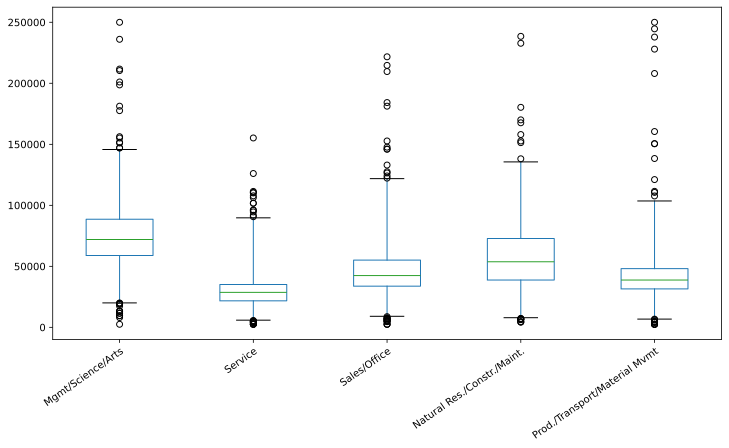

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
county_tract_acs_occupation_df.boxplot(
    ax=ax, 
    rot=35, # rotate x-axis labels for readability
    whis=(1,99) # set whiskers to 1st and 99th percentiles
)

# turn off gridlines for better readability
ax.grid(False)

# adjust x-axis label alignment and rotation
for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_rotation_mode("anchor")

plt.show()

In [26]:
income_by_degree_columns = {
    "B20004_002E": "No degree",
    "B20004_003E": "High school diploma",
    "B20004_004E": "Associate's",
    "B20004_005E": "Bachelor's",
    "B20004_006E": "Master's",
    "B20004_007E": "Graduate / Professional", 
}


education_columns = list(income_by_degree_columns.keys())

county_acs_education_df = pd.DataFrame(
    census.acs5.get(
        ["NAME"] + education_columns,
        geo={
            "for": "county:*",  
            "in": f"state:{state_fips}",
        },
        year=2023,
    )
)
county_acs_education_df = county_acs_education_df.rename(columns=income_by_degree_columns)

county_acs_education_df["GEOID"] = (
    county_acs_education_df["state"]
    + county_acs_education_df["county"]
)
county_acs_education_df = county_acs_education_df.set_index("GEOID")
county_acs_education_df = county_acs_education_df.drop(columns=["state", "county"])

sentinal_value_mask = county_acs_education_df[list(income_by_degree_columns.values())] < 0
county_acs_education_df[sentinal_value_mask] = np.nan

county_acs_education_df

,NAME,No degree,High school diploma,Associate's,Bachelor's,Master's,Graduate / Professional
GEOID,,,,,,,
17001,"Adams County, Illinois",34492.0,40281.0,40960.0,57550.0,67372.0,52205.0
17003,"Alexander County, Illinois",18092.0,43900.0,33871.0,41042.0,55550.0,46588.0
17005,"Bond County, Illinois",29519.0,34897.0,32626.0,51325.0,61546.0,48684.0
17007,"Boone County, Illinois",33445.0,42898.0,50689.0,71192.0,95680.0,61185.0
17009,"Brown County, Illinois",23750.0,43523.0,46406.0,51250.0,59286.0,49071.0
...,...,...,...,...,...,...,...
17195,"Whiteside County, Illinois",37115.0,40409.0,43100.0,59491.0,68839.0,53645.0
17197,"Will County, Illinois",35580.0,44656.0,53481.0,76481.0,91536.0,72491.0
17199,"Williamson County, Illinois",21641.0,37349.0,42131.0,59761.0,77307.0,52655.0


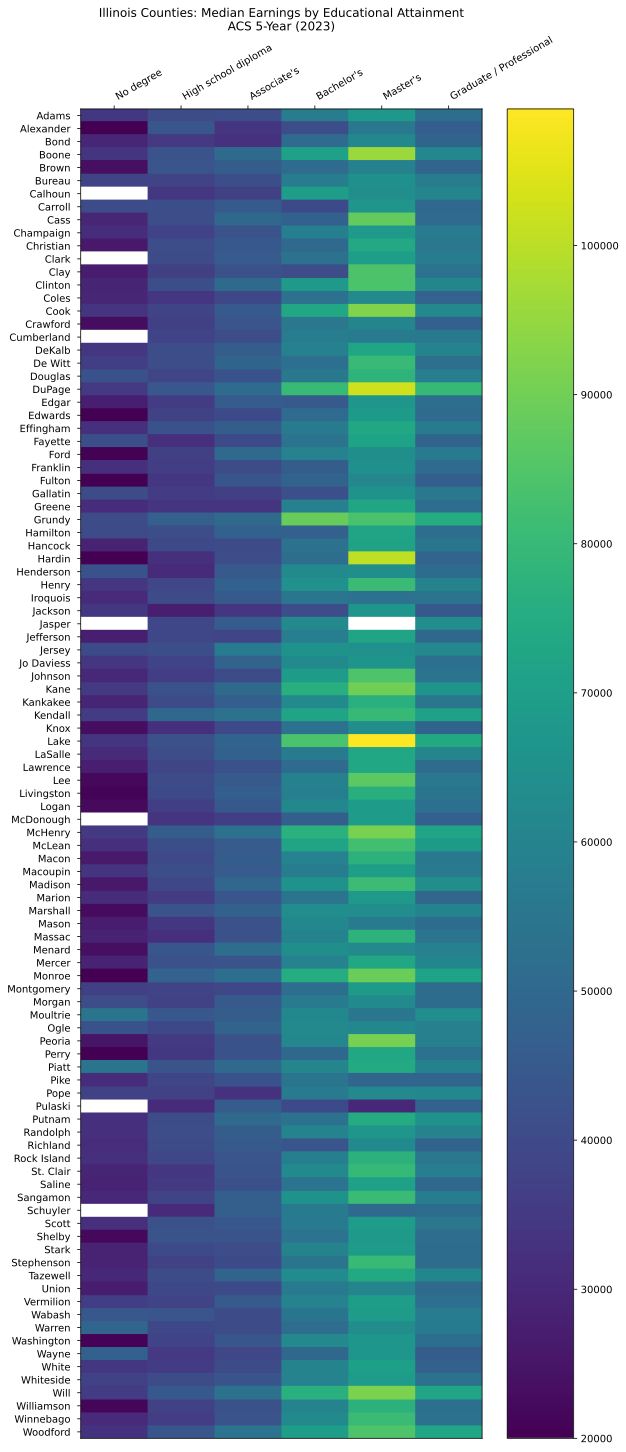

In [27]:
fig, ax = plt.subplots(figsize=(9, 24))

# This is a bit of a weird one. Matplotlib does not have a built in function for making a heatmap, 
# but we can use the imshow function to create one. The imshow function takes a 2D array of values 
# and creates a grid of colored squares where the color of each square corresponds to the value in 
# the array. This is more commonly used for visualizing images (the colors are for pixels), hence 
# the name.
image_object = ax.imshow(
    pd.DataFrame(county_acs_education_df[list(income_by_degree_columns.values())]),
    aspect="auto",
    cmap="viridis",
    vmin=20000,
)


# Now we need to adjust the tick labels to show the degree categories and county names
# instead of numbers. Don't worry about this part: it's a bit of a pain to get right but
# it's mostly just fiddly formatting code.
ax.set_xticks(range(len(income_by_degree_columns))) # make one tick for each degree category
ax.xaxis.tick_top() # move x-axis ticks to the top of the plot
ax.xaxis.set_label_position("top") # move x-axis label to the top as well

# Adjust x-axis tick labels to show degree categories
ax.set_xticklabels(
    list(income_by_degree_columns.values()),
    rotation=30,
    ha="left",  # adjust horizontal alignment of x-axis labels for better readability
)

ax.set_yticks(range(len(county_acs_education_df)))
ax.set_yticklabels(
    # We need to add the '.str' to tell pandas to apply the string replacement to each value in 
    # the "NAME" column of the dataframe.
    county_acs_education_df["NAME"].str.replace("County, Illinois", "")
)

ax.set_title(
    f"Illinois Counties: Median Earnings by Educational Attainment\nACS 5-Year ({2023})",
    pad=5,
)

# Add in the color bar
fig.colorbar(image_object, ax=ax)

plt.show()

#### TASK 3

Which tract in Cook County has the **highest median household income**? Which has the **lowest** (ignoring missing values)?

While you're at it: look up the GEOID of the highest-income tract — can you figure out what neighborhood it corresponds to?

In [28]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

#### TASK 4

Make a **scatter plot** with median household income on the x-axis and median age on the y-axis, one point per tract. Label the axes and give the plot a title. What pattern do you see?

In [29]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

## Section 4 — Joining Decennial and ACS data

Both datasets use GEOID codes as identifiers, but at different scales:
- **Block GEOID**: 15 digits — state(2) + county(3) + tract(6) + block(4)
- **Tract GEOID**: 11 digits — state(2) + county(3) + tract(6)

Since both block and tract are on the central spine of the Census geographic hierarchy, we can get the tract GEOID for any block by taking the first 11 characters of its block GEOID. Then we aggregate block counts up to the tract level and join with the ACS data.

In [30]:
# To get the tract GEOID, we take the first 11 characters of the full 15-digit block identifier
# Our block dataframe has the GEOIDs already constructed, so let's look at them for a second
block_race_df.index

Index(['170310101001000', '170310101001001', '170310101001002',
       '170310101001003', '170310101002001', '170310101002002',
       '170310101002004', '170310101002005', '170310101002006',
       '170310101002008',
       ...
       '170319801001002', '170319801001003', '170319801001005',
       '170319801001006', '170319900000002', '170319900000005',
       '170319900000001', '170319900000003', '170319900000004',
       '170319900000006'],
      dtype='str', name='GEOID20', length=83018)

The important thing to observe here is that the index column is of type "str" which is short for
"string" (as you probably guessed). Like how we can perform math operations (e.g. `sum`, `mean`) on
numeric columns, we can perform string operations on string columns. In particular, we can slice 
the string column. 

In [31]:
# This will give us the first 2 characters of the GEOID, which correspond to the state FIPS code. 
# Note that we need to use the .str accessor to apply string slicing to every item in the index;
# if we instead tried block_race_df.index[:2] we would just get the first 2 items in the index, 
# which is not what we want.
block_race_df.index.str[:2]

Index(['17', '17', '17', '17', '17', '17', '17', '17', '17', '17',
       ...
       '17', '17', '17', '17', '17', '17', '17', '17', '17', '17'],
      dtype='str', name='GEOID20', length=83018)

In [32]:
# to get the tract GEOID, we take the first 11 characters of the full 15-digit block identifier
block_race_df["tract_GEOID"] = block_race_df.index.str[:11]
block_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct,tract_GEOID
GEOID20,,,,,,,,,,,,,,,,
170310101001000,89,26,3,5,0,4,7,134,66.417910,19.402985,2.238806,3.731343,0.000000,2.985075,5.223881,17031010100
170310101001001,33,3,0,6,0,8,13,63,52.380952,4.761905,0.000000,9.523810,0.000000,12.698413,20.634921,17031010100
170310101001002,108,94,1,11,1,50,51,316,34.177215,29.746835,0.316456,3.481013,0.316456,15.822785,16.139241,17031010100
170310101001003,23,10,0,5,0,1,14,53,43.396226,18.867925,0.000000,9.433962,0.000000,1.886792,26.415094,17031010100
170310101002001,21,313,0,0,0,15,23,372,5.645161,84.139785,0.000000,0.000000,0.000000,4.032258,6.182796,17031010100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170319900000005,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17031990000
170319900000001,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17031990000
170319900000003,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17031990000


Now that we have the tracts identify, we need to aggregate the data in `block_race_df` up to the
tract level. We do this using the `group_by` method for pandas dataframes. 

In [33]:
# now we'll group the block data by tract, and aggregate each column by summing over the blocks 
# contained in each tract
county_tract_race_df = block_race_df.groupby("tract_GEOID").aggregate("sum")
county_tract_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
tract_GEOID,,,,,,,,,,,,,,,
17031010100,1652,2187,49,154,5,364,494,4905,996.655353,1084.914407,27.876751,94.797682,2.947813,188.847034,303.960960
17031010201,1832,2574,90,376,7,1262,798,6939,1415.415476,1850.308466,82.621031,283.995851,4.627647,862.275157,700.756373
17031010202,1078,767,29,147,4,400,317,2742,729.535233,530.794285,14.600810,118.537969,9.935859,304.607122,291.988722
17031010300,2963,1778,40,332,2,396,794,6305,1729.613078,1158.177625,40.926933,232.428670,3.846154,260.365919,574.641621
17031010400,3148,620,22,569,0,316,404,5079,1224.250079,276.398926,13.325098,212.977635,0.000000,109.473135,263.575128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17031844600,55,1647,2,6,0,26,40,1776,109.533484,1894.791659,1.818182,6.502129,0.000000,108.549483,78.805063
17031844700,143,1821,19,14,0,199,146,2342,284.314442,2932.096353,40.415802,41.874673,0.000000,350.486131,350.812599
17031980000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Obviously, we need to recompute the percents

In [34]:
# Let's only keep the main pl_race_categories and then recompute

county_tract_race_df = county_tract_race_df[pl_race_categories + ["total"]]
for col in pl_race_categories:
    county_tract_race_df[f"{col}_pct"] = (
        100 * county_tract_race_df[col] / county_tract_race_df["total"]
    ).fillna(0)

# Let's sort by total population really quick to check for NaNs just in case
county_tract_race_df = county_tract_race_df.sort_values("total")
county_tract_race_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct
tract_GEOID,,,,,,,,,,,,,,,
17031990000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17031980000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17031980100,6,3,0,2,1,2,4,18,33.333333,16.666667,0.000000,11.111111,5.555556,11.111111,22.222222
17031381700,2,8,0,0,0,4,4,18,11.111111,44.444444,0.000000,0.000000,0.000000,22.222222,22.222222
17031381500,16,609,3,0,0,11,28,667,2.398801,91.304348,0.449775,0.000000,0.000000,1.649175,4.197901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17031320101,6124,482,23,1943,0,191,769,9532,64.246748,5.056651,0.241292,20.383970,0.000000,2.003777,8.067562
17031081403,6251,409,15,2182,5,191,790,9843,63.507061,4.155237,0.152393,22.168038,0.050798,1.940465,8.026008
17031839000,6173,1170,34,1924,7,330,797,10435,59.156684,11.212266,0.325827,18.437949,0.067082,3.162434,7.637758


Okay, now we would like to combine our two datasets. To do this we need to make sure that the unique identifiers
-- GEOID for `county_tract_acs_df` and tract_GEOID for `county_tract_race_df` -- line up with each other.

In [35]:
# county_tract_race_df is printed just above this, so let's compare here
county_tract_acs_df

,median_age,median_income,commuters_total,transit_riders,transit_pct
GEOID,,,,,
17031400800,23.9,22648.0,1053.0,612.0,58.119658
17031070103,26.8,76477.0,1304.0,706.0,54.141104
17031670800,41.5,43145.0,451.0,241.0,53.436807
17031350400,32.5,20938.0,471.0,245.0,52.016985
17031271800,42.5,51550.0,415.0,215.0,51.807229
...,...,...,...,...,...
17031816200,37.8,92943.0,2377.0,0.0,0.000000
17031381700,NaN,NaN,0.0,0.0,NaN
17031980000,NaN,NaN,0.0,0.0,NaN


<font color='red'> Peter Note: Okay, I am getting really tired and I am not going to do well at explaining why you need to do all of these checks when working with real data </font>

In [36]:
# Check that your indices are both unique
print(county_tract_race_df.index.is_unique, county_tract_acs_df.index.is_unique)
# Check that they have the same set of GEOIDs. When the indices are unique, it's easiest to just 
# compare the sets of index values directly.
print(set(county_tract_race_df.index) == set(county_tract_acs_df.index))

True True
True


In [37]:
# We are now ready to join the dataframes together! Since they both have the same index (tract GEOID), 
# we can use panda's built in join function to combine the dataframes together. By default, pandas
# will try to use the indices of the joined dataframes to match rows together. That is why
# it's so important that the indices are unique and that they match across the two dataframes.
combined_df = county_tract_race_df.join(county_tract_acs_df)
combined_df

,White,Black,AMIN,Asian,NHPI,SomeOther,Multi,total,White_pct,Black_pct,AMIN_pct,Asian_pct,NHPI_pct,SomeOther_pct,Multi_pct,median_age,median_income,commuters_total,transit_riders,transit_pct
tract_GEOID,,,,,,,,,,,,,,,,,,,,
17031990000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,NaN
17031980000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,NaN
17031980100,6,3,0,2,1,2,4,18,33.333333,16.666667,0.000000,11.111111,5.555556,11.111111,22.222222,NaN,NaN,0.0,0.0,NaN
17031381700,2,8,0,0,0,4,4,18,11.111111,44.444444,0.000000,0.000000,0.000000,22.222222,22.222222,NaN,NaN,0.0,0.0,NaN
17031381500,16,609,3,0,0,11,28,667,2.398801,91.304348,0.449775,0.000000,0.000000,1.649175,4.197901,59.4,25019.0,203.0,94.0,46.305419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17031320101,6124,482,23,1943,0,191,769,9532,64.246748,5.056651,0.241292,20.383970,0.000000,2.003777,8.067562,40.3,129221.0,6044.0,720.0,11.912641
17031081403,6251,409,15,2182,5,191,790,9843,63.507061,4.155237,0.152393,22.168038,0.050798,1.940465,8.026008,33.0,117550.0,6749.0,923.0,13.676100
17031839000,6173,1170,34,1924,7,330,797,10435,59.156684,11.212266,0.325827,18.437949,0.067082,3.162434,7.637758,30.5,95565.0,6367.0,1097.0,17.229464


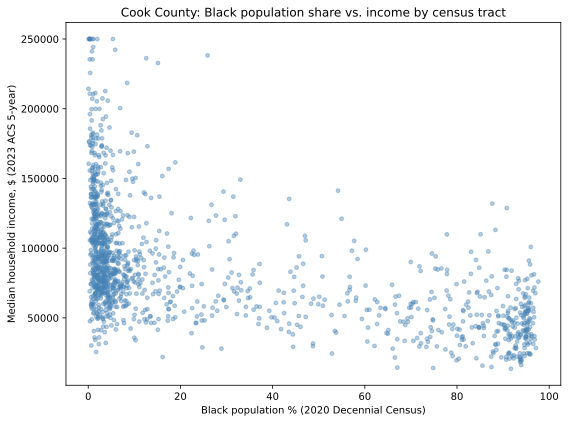

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    combined_df["Black_pct"],
    combined_df["median_income"],
    alpha=0.4,
    s=15,
    color="steelblue",
)
ax.set_xlabel("Black population % (2020 Decennial Census)")
ax.set_ylabel("Median household income, $ (2023 ACS 5-year)")
ax.set_title(f"{county_name}: Black population share vs. income by census tract")
plt.tight_layout()
plt.show()

There's a strong pattern here. But be careful about what conclusions you draw: we're looking at **tracts**, not individuals. The correlation at the aggregate level doesn't describe any individual's experience — a Black person in a high-income tract is not evidence against the pattern, and vice versa. This kind of misreading is called the [ecological fallacy](https://en.wikipedia.org/wiki/Ecological_fallacy), and it's a recurring hazard in data analysis with administrative geographies.

#### TASK 5

Choose a different racial group from `pl_race_categories`, or a different ACS variable from `county_tract_acs_df`, and make your own scatter plot. Describe what you see in a sentence or two.

In [ ]:
# YOUR CODE HERE

# raise your hand and ask for help if you get stuck!

<font color="red"> Peter is going to add another plot down here showing some varying sizes of dots using matplotlib's scatter function. <font>

## Homework 2

**Warmup question:** Among all Cook County census tracts with income data available, how many have a median household income above $100,000? What fraction of all tracts with data does that represent? Show your pandas code.

**Data product:** Choose a state other than Illinois. Fetch at least one ACS variable at the county or tract level and make at least one visualization. Write 2–3 sentences describing what you found and what further question it raises.

_Tip: the [ACS table shells](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.html) and the course [Google spreadsheet](https://docs.google.com/spreadsheets/d/1DtGNarbQLaJdtMiINQ7brQ-Y6zawBkkBkp0VGSENsZw/) are useful for finding variable codes._

**Reading response:** _(to be added by instructor)_